In [1]:
import pandas as pd
import xarray as xr
import numpy as np
import glob as glob

import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
from matplotlib.ticker import ScalarFormatter


# Aim: Visualise basin-scale circulation 
- Time averaged velocity at selected depth 
- Plot horizontal velocity fields as streamlines and quivers 


# Load bathymetry 
- for plotting purposes only 

In [4]:
path_bathy = '../../../data/lake_zug/model/'
fname_bathy = 'fine_bathy.nc'
bathy = xr.open_dataset(path_bathy + fname_bathy).depth
bathy = bathy.rename({'xsc':'X','ysc':'Y'})


# Load MITgcm data 
- Loading one month at a time 

In [5]:
run = 'model'
output = 'out2'


path = '../../../data/lake_zug/{}/{}/'.format(run,output)
ufname = glob.glob(path + "u_*")[0]
vfname = glob.glob(path + "v_*")[0]

u = xr.open_dataset(ufname, chunks={'T':1,'Z':1}).U
v = xr.open_dataset(vfname, chunks={'T':1,'Z':1}).V

In [6]:
u["T"]

<xarray.DataArray 'T' (T: 721)> Size: 6kB
array(['2025-12-31T00:00:00.000000000', '2025-12-31T01:00:00.000000000',
       '2025-12-31T02:00:00.000000000', ..., '2026-01-29T22:00:00.000000000',
       '2026-01-29T23:00:00.000000000', '2026-01-30T00:00:00.000000000'],
      shape=(721,), dtype='datetime64[ns]')
Coordinates:
  * T        (T) datetime64[ns] 6kB 2025-12-31 ... 2026-01-30
    iter     (T) int32 3kB dask.array<chunksize=(1,), meta=np.ndarray>
Attributes:
    long_name:  model_time

# Slice data to selected Z and T 
- Alternatively select only one time snapshot 


In [7]:
start_T = np.datetime64('2026-01-20T00:00:00.000000000')
end_T = np.datetime64('2026-01-21T18:00:00.000000000')
zz = -40 #depth is set as negative in mitgcm 

In [8]:
u = u.sel(T=slice(start_T,end_T))
v = v.sel(T=slice(start_T,end_T))


umean = u.mean(dim='T')
vmean = v.mean(dim='T')
speed_mean = np.sqrt(umean**2 + vmean**2)


umean_zz = umean.sel(Z=zz, method="nearest")
vmean_zz = vmean.sel(Z=zz, method="nearest")
smean_zz = speed_mean.sel(Z=zz, method="nearest")

# Plot quivers 

## Coarsen velocity fields 
- for cleaner quiver plots 

In [9]:
# Coarsen velocity fields by averaging over blocks
coarsen_factor_x = 2
coarsen_factor_y = 4

umean_coarse = umean_zz.coarsen(X=coarsen_factor_x, Y=coarsen_factor_y, boundary="trim").mean()
vmean_coarse = vmean_zz.coarsen(X=coarsen_factor_x, Y=coarsen_factor_y, boundary="trim").mean()
speed_coarse = smean_zz.coarsen(X=coarsen_factor_x, Y=coarsen_factor_y, boundary="trim").mean()

# Extract coarsened coordinate grid
X_coarse = umean_coarse['X']
Y_coarse = umean_coarse['Y']

## Interpolate speed on same bathy grid 
- this is only for plotting purposes 

In [10]:
smean_zz_interp = smean_zz.interp(X=bathy.X.values,Y=bathy.Y.values)
smean_zz_interp = smean_zz_interp.where(~np.isnan(bathy))


## Generate plot 

(np.float64(-192.0),
 np.float64(6672.0),
 np.float64(-456.0),
 np.float64(14856.0))

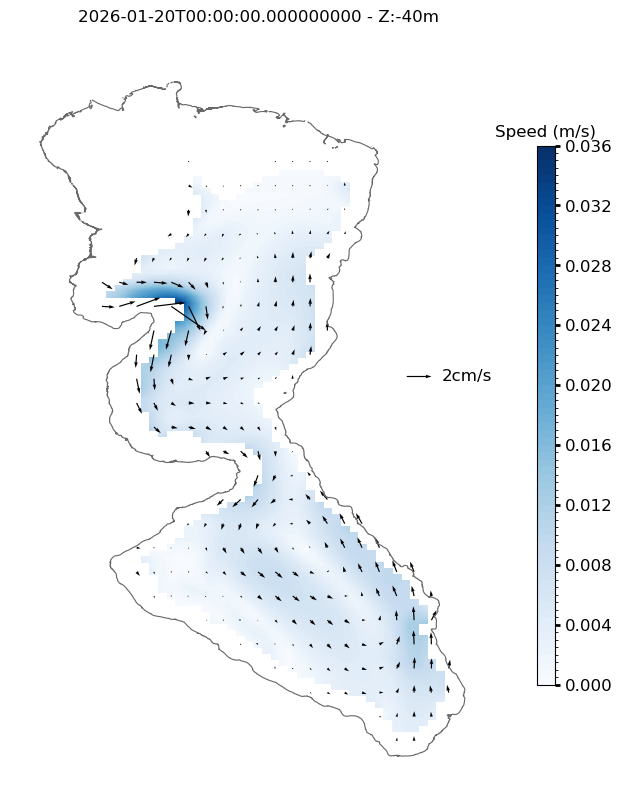

In [11]:
fig, ax = plt.subplots(1,figsize=(8, 10))

# Plot bathymetry contour 
bathy.plot.contour(levels=[-3], linestyles='solid', colors="dimgray", linewidths=0.8)
fig1 = smean_zz_interp.plot.contourf(levels=80,cmap="Blues",add_colorbar=False)

cbar = fig.colorbar(fig1, ax=ax, orientation='vertical', pad=0.05, shrink=0.7, aspect=30)
cbar.ax.tick_params(labelsize=12, width=2)
cbar.ax.yaxis.set_major_formatter(FormatStrFormatter('%.3f'))
cbar.ax.set_title('Speed (m/s)', fontsize=12)


# Use pcolormesh to fill without faint contour lines
#plt.pcolormesh(bathy.xsc, bathy.ysc, bathy, cmap="Blues_r", alpha=0.6, shading="auto")
#plt.pcolormesh(smean_zz.xsc, smean_zz.ysc, smean_zz, cmap="Blues_r", alpha=0.6, shading="auto")

# Plot velocity quivers
q = plt.quiver(X_coarse, Y_coarse, umean_coarse, vmean_coarse, scale=0.4, color='k')  

# Add a quiver key for reference velocity
plt.quiverkey(q, X=0.85, Y=0.55, U=0.02, label='2cm/s', labelpos='E', fontproperties={'size': 12})
plt.title('{} - Z:{}m'.format(start_T,zz))

plt.axis('off')

# Plot streamlines 

## Format shape of xarray + compute KE

In [12]:
X = u.X.values
Y = u.Y.values

# Ensure shape is (Y, X) for streamplot
u_c = umean_zz.transpose('Y', 'X').values
v_c = vmean_zz.transpose('Y', 'X').values

ke = (u_c**2 + v_c**2) ** 0.5

(np.float64(60.0), np.float64(6420.0), np.float64(60.0), np.float64(14340.0))

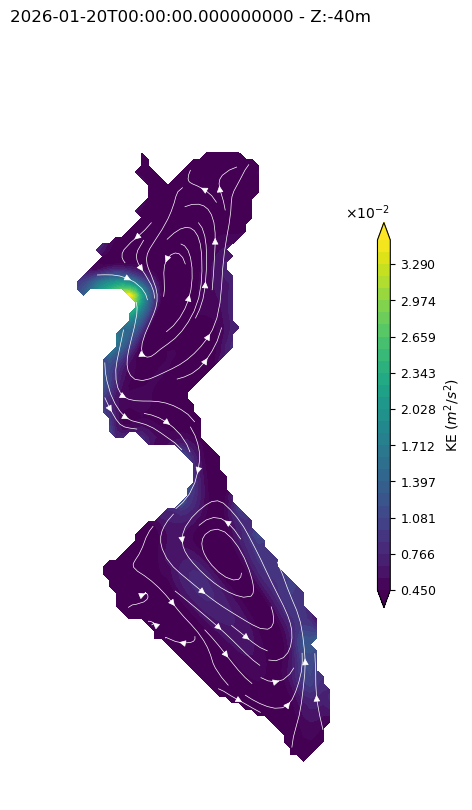

In [13]:
ke_min = 4.5e-3; ke_max = 3.5e-2
levels = np.linspace(ke_min, ke_max, 30)

fig, ax = plt.subplots(1, figsize=(10, 10))
cf = ax.contourf(X, Y, ke, levels=levels, cmap='viridis', 
                 vmin=ke_min, vmax=ke_max, extend='both')
cbar = fig.colorbar(cf, ax=ax, label='KE $(m^2/s^2)$', 
                    shrink=0.5, aspect=30, pad=0.02)

# Scientific notation on colorbar
formatter = ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((-2, 2))  # force sci notation in this range
cbar.ax.yaxis.set_major_formatter(formatter)
cbar.ax.tick_params(labelsize=9)

ax.streamplot(X, Y, u_c, v_c, density=1.5, linewidth=0.5, color='w')
ax.set_aspect('equal')
ax.set_title('{} - Z:{}m'.format(start_T,zz))
ax.axis('off')